# Final Project Phase 3 Summary
This Jupyter Notebook (.ipynb) will serve as the skeleton file for your submission for Phase 3 of the Final Project. Complete all sections below as specified in the instructions for the project, covering all necessary details. We will use this to grade your individual code (Do this whether you are in a group or not). Good luck! <br><br>

Note: To edit a Markdown cell, double-click on its text.

# Video Presentation

If you uploaded your Video Presentation to Bluejeans, YouTube, or any other streaming services, please provide the link here:


*   https://youtu.be/gbyQtyGz6BE


Make sure the video sharing permissions are accessible for anyone with the provided link.

## Data Sources

Include sources (as links) to your datasets. If any of these are different from your sources used in Phase II, please <b>clearly</b> specify.

*   Downloaded Dataset Source: https://data.cityofnewyork.us/Public-Safety/Motor-Vehicle-Collisions-Crashes/h9gi-nx95/data_preview;
- Google Drive Link to Downloaded Dataset: https://drive.google.com/file/d/1GBqx85GOOHZApsViUlEiEHRHjWCwtkeo/view?usp=sharing
*   Web Collection #1 Source: https://www.walkscore.com/NY/New_York (New York Neighborhoods table)
*   Web Collection #2 Source: https://api.census.gov/data/2024/acs/acs5?get=NAME,B19013_001E,B08301_019E,B08301_010E,B25044_003E,B01003_001E&for=zip%20code%20tabulation%20area:*&key=5771b86a16a9999b827c3d2ef7dda48b07ab7815



# Data Collection and Cleaning


Transfer/update the data collection and cleaning you created for Phase II below. You may include additional cleaning functions if you have extra datasets. If no changes are necessary, simply copy and paste your phase II parsing/cleaning functions.


## Downloaded Dataset Requirement



In [259]:
import pandas as pd
from uszipcode import SearchEngine

def downloaded_dataset_parser(csv_file):
  df = pd.read_csv(csv_file)
  df = df.drop(columns=["LATITUDE","LONGITUDE","ON STREET NAME","CROSS STREET NAME",
                        "OFF STREET NAME","NUMBER OF PERSONS INJURED","NUMBER OF PERSONS KILLED",
                        "NUMBER OF CYCLIST INJURED","NUMBER OF CYCLIST KILLED","NUMBER OF MOTORIST INJURED",
                        "NUMBER OF MOTORIST KILLED","COLLISION_ID"])
  
  df = df.iloc[:,:7]
  
  df["ZIP CODE"] = df["ZIP CODE"].fillna(0)
  df["ZIP CODE"] = df["ZIP CODE"].astype(str).str.strip().replace("",0)
  df["ZIP CODE"] = df["ZIP CODE"].astype(float).astype(int).astype(str)

  df["LOCATION"] = df["LOCATION"].fillna("(0, 0)")
  df["LOCATION"] = df["LOCATION"].str.strip()
  
  df = df[(df["ZIP CODE"] != "0") | (df["LOCATION"] != "(0, 0)")]

  df["BOROUGH"] = df["BOROUGH"].fillna("UNKNOWN")
  df["CRASH DATE"] = pd.to_datetime(df["CRASH DATE"]).dt.year

  df = df.rename(columns={"CRASH DATE":"CRASH YEAR"})

  df = df.dropna()

  df["NUMBER OF PEDESTRIANS AFFECTED"] = df["NUMBER OF PEDESTRIANS INJURED"] + df["NUMBER OF PEDESTRIANS KILLED"]
  
  df.to_csv("csv_output.csv", index=False)

  return df

def get_zip_code(df):
  unique_locations = df[df["ZIP CODE"] == 0]["LOCATION"].unique() # gets all of the unique latitute/longitude coordinates since there are repeats

  search = SearchEngine() # SearchEngine object used to run the by_coordinates method
  locationDict = {}

  for location in unique_locations:
      latitude_longitude = location.strip('()').split(',')
      latitude, longitude = float(latitude_longitude[0]), float(latitude_longitude[1])
      
      result = search.by_coordinates(latitude, longitude, radius=1, returns=1) # by_coordinates method lets you find a zip code by latitude/longitude within a certain radius (in this case 1)

      if result:
          locationDict[location] = result[0].zipcode # gets the zipcode value from the result of the by_coordinates method
      else: 
          locationDict[location] = 0

  df[df["ZIP CODE"] == 0]["ZIP CODE"] = df[df["ZIP CODE"] == 0]["LOCATION"].map(locationDict) # uses the Pandas .map method to map the calculated zip codes to the right locations in the DataFrame
  df["ZIP CODE"] = df["ZIP CODE"].fillna(0)

  df = df[df["ZIP CODE"] != 0]

  df.to_csv("final_csv_output.csv", index=False)

  return df
    
############ Function Call ############
df = downloaded_dataset_parser("Motor Vehicle Dataset.csv")

df = pd.read_csv("csv_output.csv")
df = get_zip_code(df)

print(df.head(10))

/var/folders/xs/r1jtw3y5665395typ4r_12g00000gn/T/ipykernel_2856/3117011575.py:5: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_file)
/var/folders/xs/r1jtw3y5665395typ4r_12g00000gn/T/ipykernel_2856/3117011575.py:52: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[df["ZIP CODE"] == 0]["ZIP CODE"] = df[df["ZIP CODE"] == 0]["LOCATION"].map(locationDict) # uses the Pandas .map method to map the calculated zip codes to the right locations in the DataFrame


    CRASH YEAR CRASH TIME    BOROUGH  ZIP CODE                 LOCATION  \
0         2023       1:29   BROOKLYN     11230   (40.62179, -73.970024)   
1         2021       9:35   BROOKLYN     11208    (40.667202, -73.8665)   
2         2021       8:13   BROOKLYN     11233  (40.683304, -73.917274)   
4         2021       8:17      BRONX     10475    (40.86816, -73.83148)   
5         2021      21:10   BROOKLYN     11207     (40.67172, -73.8971)   
6         2021      14:58  MANHATTAN     10017    (40.75144, -73.97397)   
8         2021      16:50     QUEENS     11413   (40.675884, -73.75577)   
10        2021      23:10     QUEENS     11434    (40.66684, -73.78941)   
11        2021      17:58   BROOKLYN     11217    (40.68158, -73.97463)   
12        2021      20:03   BROOKLYN     11226    (40.65068, -73.95881)   

    NUMBER OF PEDESTRIANS INJURED  NUMBER OF PEDESTRIANS KILLED  \
0                               0                             0   
1                               0       

## Web Collection Requirement \#1


In [260]:
import requests

def json_api_parser(url):
  api_key = "5771b86a16a9999b827c3d2ef7dda48b07ab7815"
  data = requests.get(url + api_key).json()
  
  df = pd.DataFrame(data = data[1:], columns = data[0])
  df = df.drop(["NAME"], axis = 1)
  df = df.rename(columns = {"zip code tabulation area" : "zip_code", "B19013_001E" : "median_household_income", "B08301_019E" : "walk_to_work", "B08301_010E" : "public_transport_work", "B01003_001E" : "total_population"})
  df = df[df["zip_code"].str.match(r"^1(0[0-9]|1[0-6])\d{2}$")]
  df = df.set_index("zip_code")

  df.to_csv("final_api_output.csv", index = True)
  return df

############ Function Call ############
df = json_api_parser("https://api.census.gov/data/2024/acs/acs5?get=NAME,B19013_001E,B08301_019E,B08301_010E,B01003_001E&for=zip%20code%20tabulation%20area:*&key=")
print(df.head(10))

         median_household_income walk_to_work public_transport_work  \
zip_code                                                              
10001                     129852         4658                  6403   
10002                      48386         6954                 14754   
10003                     154262         7557                 10677   
10004                     250001          644                   905   
10005                     190233         1359                  3680   
10006                     190170          450                  1342   
10007                     250001          936                  1908   
10009                      92876         5154                 14576   
10010                     144969         4390                  6180   
10011                     145987         5737                 11626   

         total_population  
zip_code                   
10001               30511  
10002               76873  
10003               53560  
10004  

## Web Collection Requirement #2

In [261]:
from bs4 import BeautifulSoup
import requests
import pandas as pd
from io import StringIO

def find_match(scraped_name, new_map):
    for map_name in new_map.index:
        if scraped_name in map_name:
            return new_map[map_name]
    return "[]"

def html_parser(url):
    map_df = pd.read_csv("NeighborhoodToZipCode.csv")

    map_df['UHFNAME'] = map_df['UHFNAME'].str.strip().str.upper()
    map_df = map_df.rename(columns={"UHFNAME":"Neighborhood"})

    new_map = map_df.groupby("Neighborhood")["ZCTA"].apply(list)

    response = requests.get(url)
    soup = BeautifulSoup(response.text, 'html.parser')
    
    table = soup.find("table",{"id":"hoods-list-table"})
    rows = table.find("tbody").find_all("tr")

    data = []
    for row in rows:
        cols = row.find_all("td")
        if len(cols) > 0:
            name = cols[1].text.strip()
            walk_score = cols[2].text.strip()

            data.append({
                "Name": name,
                "Walk Score": walk_score
            })

    df = pd.DataFrame(data)
    
    df["Name"] = df["Name"].str.strip().str.upper()
    df['Zip Codes'] = df['Name'].apply(find_match, args=(new_map,))
        
    df.to_csv("final_web_output.csv", index=False)
    return df

############ Function Call ############
df = html_parser("https://www.walkscore.com/NY/New_York")
print(df.head(10))

              Name Walk Score  \
0     UNION SQUARE        100   
1        CHINATOWN        100   
2             NOHO        100   
3     WEST VILLAGE        100   
4             SOHO         99   
5          TRIBECA         99   
6     MIDTOWN EAST         99   
7         KIPS BAY         99   
8          CHELSEA         99   
9  UPPER EAST SIDE         99   

                                           Zip Codes  
0                              [10002, 10003, 10009]  
1                                                 []  
2                                                 []  
3                                                 []  
4                              [10012, 10013, 10014]  
5                                                 []  
6                                                 []  
7                                                 []  
8  [10001, 10011, 10018, 10019, 10020, 10036, 101...  
9  [10021, 10028, 10044, 10065, 10075, 10128, 10162]  


In [262]:
from ast import literal_eval 

def join_data():
    df_crash = pd.read_csv("final_csv_output.csv")
    df_census = pd.read_csv("final_api_output.csv")
    df_walkability = pd.read_csv("final_web_output.csv")

    df_walkability['Zip Codes'] = df_walkability['Zip Codes'].apply(literal_eval) # literal_eval: https://stackoverflow.com/questions/23111990/pandas-dataframe-stored-list-as-string-how-to-convert-back-to-list, https://docs.python.org/3/library/ast.html
    df_walkability = df_walkability.explode('Zip Codes').rename(columns={'Zip Codes': 'zip_code'}).dropna() # explode: https://stackoverflow.com/questions/12680754/split-explode-pandas-dataframe-string-entry-to-separate-rows, https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.explode.html
    
    df_crash['ZIP CODE'] = df_crash['ZIP CODE'].astype(str)
    df_census['zip_code'] = df_census['zip_code'].astype(str)
    df_walkability['zip_code'] = df_walkability['zip_code'].astype(str)

    df = pd.merge(df_crash, df_census, left_on='ZIP CODE', right_on='zip_code', how='inner')
    df = pd.merge(df, df_walkability, on='zip_code', how='left')
    
    df = df[df['median_household_income'] > 0]

    return df

df = join_data()
df.to_csv("final_csv.csv", index=False)

print(df)

         CRASH YEAR CRASH TIME   BOROUGH ZIP CODE                 LOCATION  \
0              2023       1:29  BROOKLYN    11230   (40.62179, -73.970024)   
1              2021       9:35  BROOKLYN    11208    (40.667202, -73.8665)   
2              2021       8:13  BROOKLYN    11233  (40.683304, -73.917274)   
3              2021       8:17     BRONX    10475    (40.86816, -73.83148)   
4              2021      21:10  BROOKLYN    11207     (40.67172, -73.8971)   
...             ...        ...       ...      ...                      ...   
1956159        2025       9:00    QUEENS    11358    (40.76715, -73.79269)   
1956160        2025      14:13     BRONX    10461    (40.84444, -73.83558)   
1956161        2025      15:48  BROOKLYN    11224   (40.576946, -73.98312)   
1956162        2025      15:48  BROOKLYN    11224   (40.576946, -73.98312)   
1956163        2025      13:19    QUEENS    11103   (40.760567, -73.91549)   

         NUMBER OF PEDESTRIANS INJURED  NUMBER OF PEDESTRIANS K

## Inconsistency Revisions
 **If you were requested to revise your inconsistency section from Phase II, enter your responses here. Otherwise, ignore this section.**

For each inconsistency (NaN, null, duplicate values, empty strings, etc.) you discover in your datasets, write at least 2 sentences stating the significance, how you identified it, and how you handled it.

1. 

2. 

3. 

4. (if applicable)

5. (if applicable)


# Data Analysis
For the Data Analysis section, you are required to utilize your data to complete the following:

*   Create at least 5 insights
*   Generate at least 3 data visualizations

Create a function for each of the following sections mentioned above. Do not forget to fill out the explanation section for each function. 

Make sure your data analysis is not too simple. Performing complex aggregation and using modules not taught in class shows effort, which will increase the chance of receiving full credit. 

# Topic Summary

Our topic analyzes the relationship between the walkability of neighborhoods, income levels, most common mode of transportation, and pedestrian accident data in New York City. We used the US Census API, a NYC neighborhood walkability score website, and live accident records from car crashes in NYC. We wanted to find out whether more walkable neighborhoods experienced more pedestrian injuries from car crashes, as well as the potential connection between higher income neighborhoods being more walkable. Our findings reveal that highly walkable neighborhoods experience higher rates of pedestrian injury, likely due to increased exposure. Furthermore, our other analyses found that lower income neighborhoods suffered from more accidents compared to wealthier neighborhoods. These insights collectively provide data that proves that NYC should prioritze accident prevention infrastructure in lower-income transit hubs to mitigate injuries and deaths.

## Insights

In [271]:
from sklearn.linear_model import LinearRegression
import numpy as np

def insight1_regression():
    X = df.dropna()[['total_population', 'Walk Score']]
    y = df.dropna()['NUMBER OF PEDESTRIANS AFFECTED']

    model = LinearRegression().fit(X, y)
    print(f"Walk Score and Population vs Pedestrians Affected R^2: {model.score(X, y)}")

def insight1_quantiles():
    top_10_walk_score = df[df['Walk Score'] >= df['Walk Score'].quantile(0.9)] # quantile: https://stackoverflow.com/questions/69517529/how-to-find-the-top-any-of-a-dataframe, https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.quantile.html
    bottom_10_walk_score = df[df['Walk Score'] <= df['Walk Score'].quantile(0.1)] 
    
    top_pedestrian_risk = top_10_walk_score.groupby('zip_code')['NUMBER OF PEDESTRIANS AFFECTED'].sum().mean()
    bottom_pedestrian_risk = bottom_10_walk_score.groupby('zip_code')['NUMBER OF PEDESTRIANS AFFECTED'].sum().mean()
    
    print(f"Top 10% Risk: {top_pedestrian_risk}")
    print(f"Bottom 10% Risk: {bottom_pedestrian_risk}")
    print(f"Percent Difference: {((top_pedestrian_risk - bottom_pedestrian_risk) / bottom_pedestrian_risk) * 100}%")

############ Function Call ############
insight1_regression()
insight1_quantiles()

Walk Score and Population vs Pedestrians Affected R^2: 0.0009731198157182375
Top 10% Risk: 657.0
Bottom 10% Risk: 487.63157894736844
Percent Difference: 34.73286562331354%


### Insight 1 Explanation

Our linear regression model resulted in a low R^2 of 0.0009, meaning that population and walkability do not follow a linear relationship with pedestrian accidents. To derive a more meaningful insight, we analyzed the different between the top 10% and bottom 10% walkable neighborhoods, revealing a much clearer trend. By comparing the top and bottom 10% of the dataset, we found that the most walkable neighborhoods experienced a 34.73% higher average risk of pedestrian injury or death compared to the least walkable zones. This points to higher walkability having some negative effect on pedestrian safety in a way that a linear regression model was unable to determine. Although higher walkability is beneficial for moving around in a city, this could create a risk to people due to the fact that more pedestrians increases the probability of getting into an accident with a car. 

In [264]:
from sklearn.cluster import KMeans

def insight2_income_injuries():
  cluster_df = df.groupby('ZIP CODE').agg({
    'median_household_income': 'mean', 
    'NUMBER OF PEDESTRIANS AFFECTED': 'sum'
  })

  cluster_df = cluster_df.dropna()
  
  kmeans = KMeans(n_clusters=3, random_state=42)
  kmeans.fit(cluster_df)

  print("Income vs Injuries:")
  print(kmeans.cluster_centers_)

def insight2_income_walkscores():
  cluster_df = df.groupby('zip_code').agg({
    'median_household_income': 'mean',
    'Walk Score': 'mean'
  })

  cluster_df = cluster_df.dropna()

  kmeans = KMeans(n_clusters=3, random_state=42)
  kmeans.fit(cluster_df)

  print("Income vs Walk Score:")
  print(kmeans.cluster_centers_)

############ Function Call ############
insight2_income_injuries()
insight2_income_walkscores()

Income vs Injuries:
[[ 70908.33    953.03]
 [125888.87    466.83]
 [206533.62    302.  ]]
Income vs Walk Score:
[[ 53617.84     87.5 ]
 [ 92018.67     86.47]
 [146591.38     92.71]]


### Insight 2 Explanation

We used K-Means clustering to categorize NYC neighborhoods into three different areas, revealing that there is a clear disparity in how infrastructure and safety are associated with wealth. In the income vs injuries model, we found that the lowest income cluster (around 71000) has over 3 times the average injuries compared to the highest income cluster (around 206000). Meanwhile, the income vs walk score model found that the wealthiest neighborhoods (around 146000) have the highest average walkability. These findings prove that in NYC, lower-income neighborhoods have lower walkability scores yet still have the highest rate of pedestrian injuries or death. This means that there is an underlying relationship of lower income level correlating with more injuries at the same time as potential harms from higher walkability as shown in the last insight.

In [ ]:
def insight3():
    df['Income Levels'] = pd.qcut(df['median_household_income'], q=3, labels=["Low", "Medium", "High"]) # qcut: https://stackoverflow.com/questions/67434627/how-can-i-split-my-data-in-pandas-into-specified-buckets-e-g-40-40-20, https://pandas.pydata.org/docs/reference/api/pandas.qcut.html
    pedestrians_by_income = df.groupby('Income Levels', observed=True)['NUMBER OF PEDESTRIANS AFFECTED'].mean() # Python compiler said to pass observed = True to get rid of a warning that appeared when running this code
    
    print("Average Pedestrians per Crash by Income Level:")
    print(pedestrians_by_income)

############ Function Call ############
insight3()

Average Pedestrians per Crash by Income Level:
Income Levels
Low       0.082430
Medium    0.071340
High      0.059713
Name: NUMBER OF PEDESTRIANS AFFECTED, dtype: float64


### Insight 3 Explanation

We separated NYC zip codes into three equal income levels to analyze whether or not accidents are more severe (more pedestrians affected per crash) in certain levels. Our code resulted in a negative correlation between income and severity, as accidents in low income neighborhoods are 38% more severe than accidents in high income areas. This suggests that lower income neighborhoods potentially suffer from a lack of pedestrian infrastructure, such as wider sidewalks or barriers for cars, which results in accidents causing more injuries and deaths. This aligns with our previous insights, which proved that lower income levels have lower walkability and higher accident rates.

In [266]:
def insight4():
  borough_risks = df.groupby('BOROUGH').apply(
    lambda x: (x['NUMBER OF PEDESTRIANS AFFECTED'].sum() / x['total_population'].sum()) * 10000,
    include_groups=False # Python compiler said to pass include_groups = False to get rid of a warning and future-proof the code
  )

  print("Average Pedestrian Injuries and Deaths by Borough")
  print(borough_risks)

############ Function Call ############
insight4()

Average Pedestrian Injuries and Deaths by Borough
BOROUGH
BRONX            0.012503
BROOKLYN         0.010068
MANHATTAN        0.016848
QUEENS           0.012063
STATEN ISLAND    0.009837
dtype: float64


### Insight 4 Explanation

We normalized and calculated the risk of pedestrian injuries or deaths by NYC's five boroughs (number of pedestrians affected per 10,000 residents). We aggregated population data from the Census API against incident data from the NYC crash dataset to find that Manhattan has the highest statistical risk of pedestrian accidents. This finding shows that despite boroughs like Brooklyn having high total injury counts, the injury and death rate per capita in areas like Manhattan is higher. This could be explained by the fact that a high density of people and high volume of pedestrian traffic in Manhattan creates riskier environments.

In [267]:
def insight5():
  df['Primary_Commute'] = df.apply(
    lambda x: 'Walk' if x['walk_to_work'] > x['public_transport_work'] else 'Transit', axis=1
  )

  commute_pedestrians  = df.groupby('Primary_Commute')['NUMBER OF PEDESTRIANS AFFECTED'].mean()
  
  print(commute_pedestrians)

############ Function Call ############
insight5()

Primary_Commute
Transit    0.071373
Walk       0.067189
Name: NUMBER OF PEDESTRIANS AFFECTED, dtype: float64


### Insight 5 Explanation

We categorized NYC zip codes based on the most prominent mode of travel in each zip code. If a zip code had more people taking public transportation than walking, it was categorized as "Walk". Otherwise, it was categorized as "Transit". By aggregating the average number of pedestrians affected per crash, we found that neighborhoods where the majority of residents commute using public transportation had a 6.2% higher risk per incident compared to neighborhoods where residents mostly walked to work. This implies that areas around major transit stations (buses, subways) may be more dangerous for pedestrians than neighborhoods designed for walkability.

## Data Visualizations

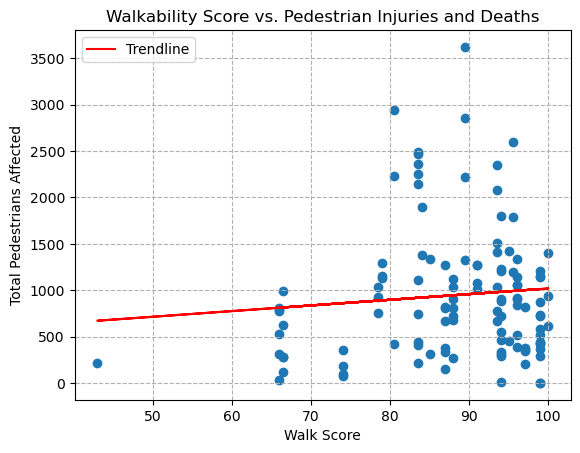

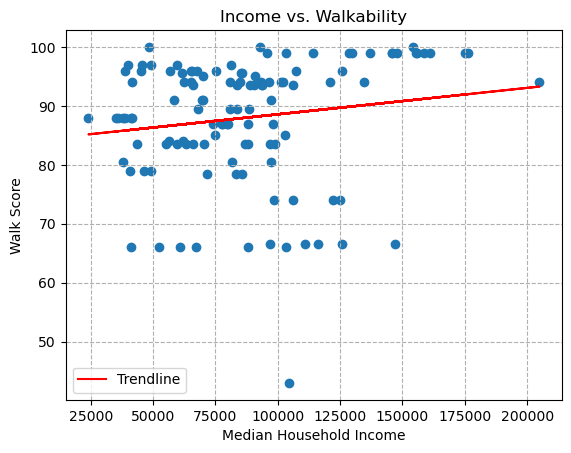

In [268]:
import matplotlib.pyplot as plt
import numpy as np

def visual1_pedestrians():
    visualization_df = df.groupby('zip_code').agg({
        'Walk Score': 'mean',
        'NUMBER OF PEDESTRIANS AFFECTED': 'sum'
    })

    visualization_df = visualization_df.dropna()
    
    x = visualization_df['Walk Score']
    y = visualization_df['NUMBER OF PEDESTRIANS AFFECTED']
    
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)

    plt.scatter(x, y)
    plt.plot(x, p(x), color='red', label="Trendline")
    
    plt.title("Walkability Score vs. Pedestrian Injuries and Deaths")
    plt.xlabel("Walk Score")
    plt.ylabel("Total Pedestrians Affected")
    
    plt.legend()
    plt.grid(True, linestyle='--')
    plt.savefig("visual1_pedestrians")
    plt.show()

def visual1_income():
    visualization_df = df.groupby('zip_code').agg({
        'median_household_income': 'mean',
        'Walk Score': 'mean'
    })

    visualization_df = visualization_df.dropna()
    
    x = visualization_df['median_household_income']
    y = visualization_df['Walk Score']
    
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)

    plt.scatter(x, y)
    plt.plot(x, p(x), color='red', label="Trendline")
    
    plt.title("Income vs. Walkability")
    plt.xlabel("Median Household Income")
    plt.ylabel("Walk Score")
    
    plt.legend()
    plt.grid(True, linestyle='--')
    plt.savefig("visual1_income")
    plt.show()


############ Function Call ############
visual1_pedestrians()
visual1_income()

### Visualization 1 Explanation

The first visualization models the relationship between neighborhood walkability and pedestrian safety. The data seems heavily scattered, but the trendline shows that there is a positive correlation between the two variables. This suggests that as the walk score increases, the total number of pedestrians affected by accidents also increases. The graph indicates that higher walkability that encourages more pedestrian activity can increases the probability of getting into a pedestrian-vehicle accident. 

We also made another scatter plot visualization that helps to analyze the income levels vs walkability scores. The trendline shows that there is a positive correlation between the two variables, implying that zip codes with higher incomes have more walkable neighborhoods. This visualization finds that the highest walk scores are concentrated in wealthier areas, proving that infrastructure access in NYC is influenced by income.

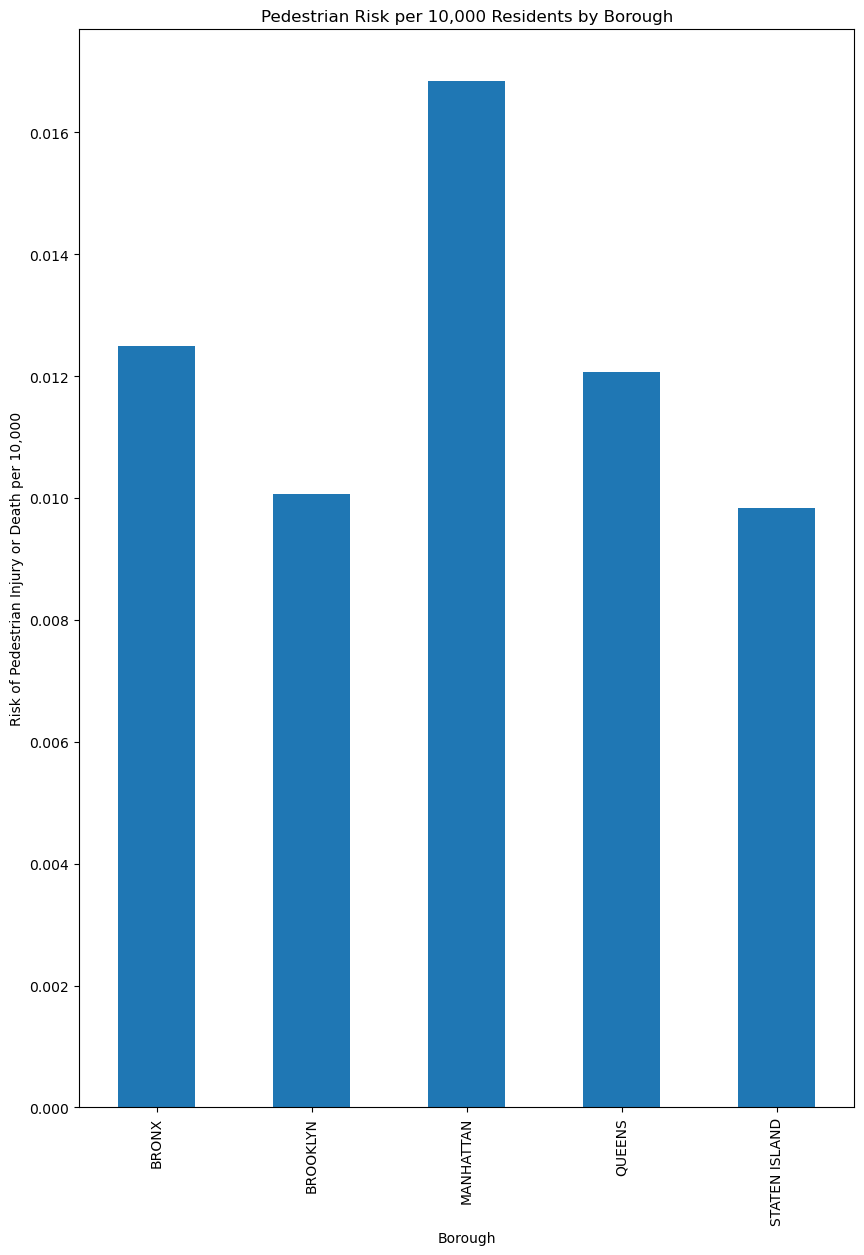

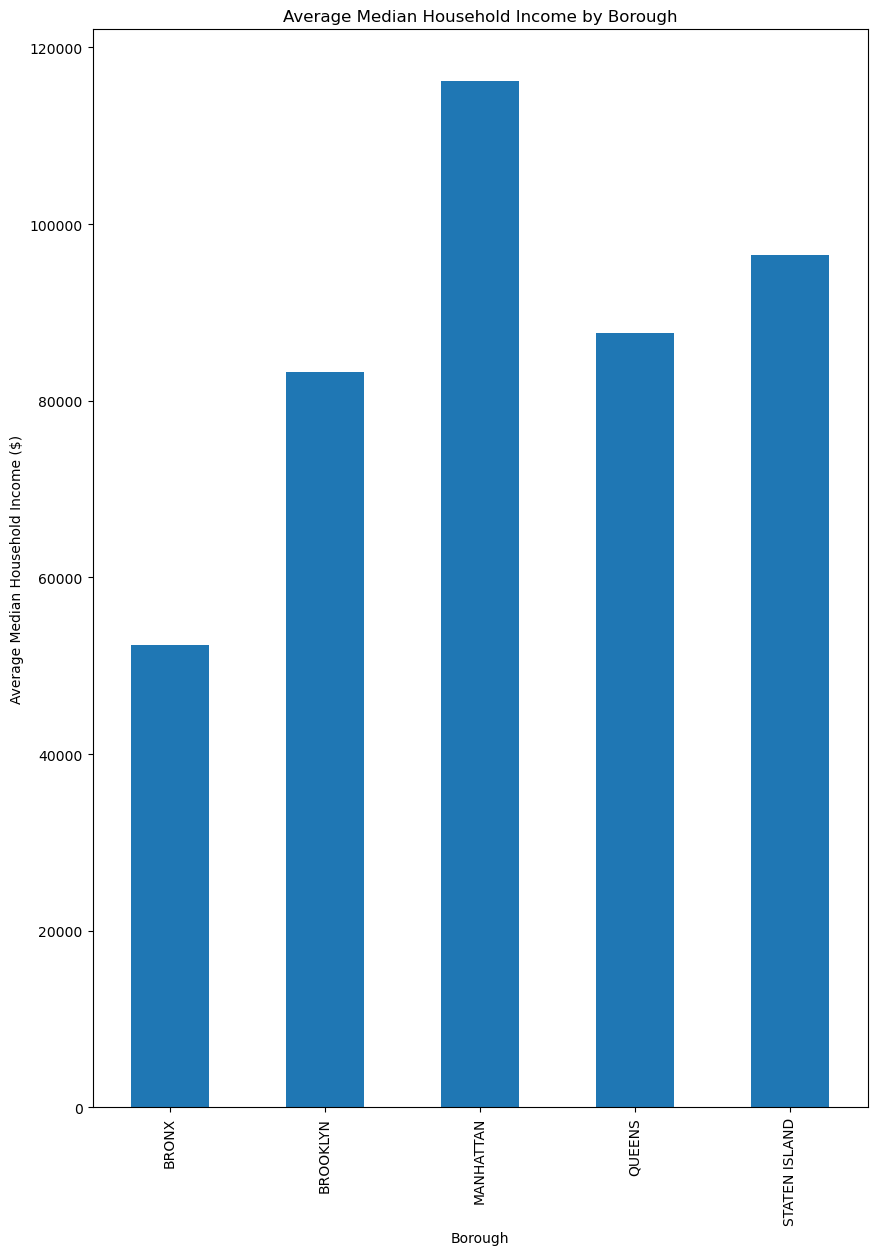

In [269]:
def visual2_pedestrians():
    borough_risk = df.groupby('BOROUGH').apply(
        lambda x: (x['NUMBER OF PEDESTRIANS AFFECTED'].sum() / x['total_population'].sum()) * 10000,
        include_groups=False # Python compiler said to pass include_groups = False to get rid of a warning and future-proof the code
    )

    plt.figure(figsize=(10,14))

    borough_risk.plot(kind='bar')

    plt.title("Pedestrian Risk per 10,000 Residents by Borough")
    plt.ylabel("Risk of Pedestrian Injury or Death per 10,000")
    plt.xlabel("Borough")

    plt.savefig("visual2_pedestrians")
    plt.show()

def visual2_income():
    borough_income = df.groupby('BOROUGH')['median_household_income'].mean()
    
    fig, ax = plt.subplots(figsize=(10,14))
    
    borough_income.plot(kind='bar', ax=ax)
    
    plt.title("Average Median Household Income by Borough")
    plt.ylabel("Average Median Household Income ($)")
    plt.xlabel("Borough")
    
    plt.savefig("visual2_income")
    plt.show()


############ Function Call ############
visual2_pedestrians()
visual2_income()

### Visualization 2 Explanation

We created a bar chart that normalizes risk to compare pedestrian safety across NYC's boroughs. By dividing the total number of people affected by the total population (per 10,000), we accounted for different population densities and revealed that Manhattan has the highest risk of injury or death. This finding suggests that Manhattan's combination of high population of commuters, tourist traffic, and other factors creates a more dangerous environment for pedestrians.

We also created another bar chart that provides more context in relation to income levels. The second visualization aggregates Census API data to determine the average wealth distribution across the city. Manhattan is once again the outlier, with the highest average median household income. When compared with the other bar chart, we can see that the actual characteristics of each borough contribute to the overall pedestrian risk along with the income levels as shown through previous insights.

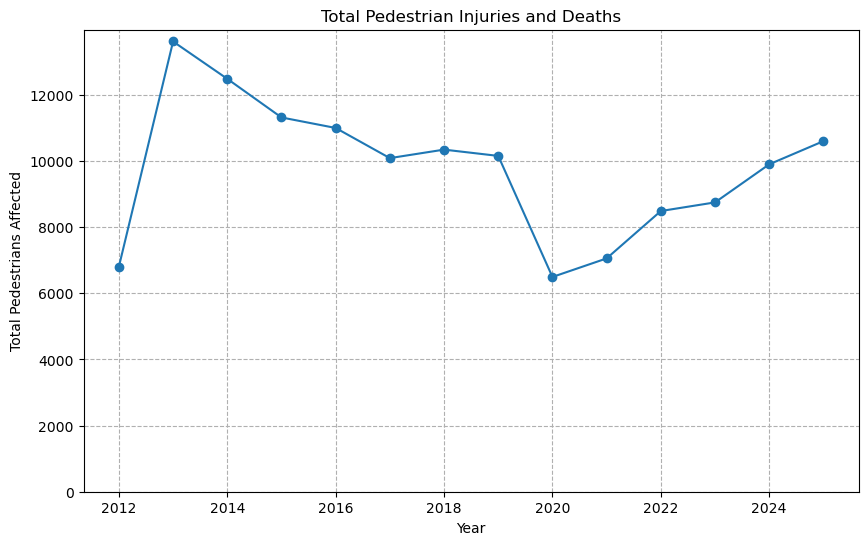

In [270]:
def visual3():
  yearly = df[df['CRASH YEAR'] != 2026].groupby('CRASH YEAR')['NUMBER OF PEDESTRIANS AFFECTED'].sum()

  plt.figure(figsize=(10,6))

  yearly.plot(kind = 'line', marker = 'o')
  plt.title("Total Pedestrian Injuries and Deaths")
  plt.xlabel("Year")
  plt.ylabel("Total Pedestrians Affected")

  plt.ylim(ymin=0) # https://stackoverflow.com/questions/22642511/change-y-range-to-start-from-0-with-matplotlib, https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.ylim.html
  
  plt.grid(True, linestyle='--')
  
  plt.savefig("visual3")
  plt.show()

############ Function Call ############
visual3()

### Visualization 3 Explanation

This visualization tracks the annual pedestrian injuries and deaths from 2012 to 2025, providing a historical benchmark for our other analyses. There is a sharp decline in 2020, which corresponds to the COVID pandemic and lower foot/car traffic in general. There is an upward trend from 2021 to 2025, showing that the total number of pedestrian injuries and deaths are returning to normal levels. This visualization provides insight into whether or not pedestrian injuries and deaths are a valid concern in modern times.

# Cited Sources

If you used any additional sources to complete your Data Analysis section, list them here:


*   Quantile: https://stackoverflow.com/questions/69517529/how-to-find-the-top-any-of-a-dataframe, https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.quantile.html
*   literal_eval: https://stackoverflow.com/questions/23111990/pandas-dataframe-stored-list-as-string-how-to-convert-back-to-list, https://docs.python.org/3/library/ast.html
*   explode: https://stackoverflow.com/questions/12680754/split-explode-pandas-dataframe-string-entry-to-separate-rows, https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.explode.html
*   qcut: https://stackoverflow.com/questions/67434627/how-can-i-split-my-data-in-pandas-into-specified-buckets-e-g-40-40-20, https://pandas.pydata.org/docs/reference/api/pandas.qcut.html
*   np.polyfit: https://stackoverflow.com/questions/41635448/how-can-i-draw-scatter-trend-line
    



# Submission

Prior to submitting your notebook to Gradescope, be sure to <b>run all functions within this file</b>. We will not run your functions ourselves, so we must see your outputs within this file in order to receive full credit.
